<a href="https://colab.research.google.com/github/janbalangue/SQL-to-Python-Cloud-Notebook-Workflow/blob/master/sql_modern_workflows_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: SQL-to-Python Cloud Notebook Workflow

## Scenario: Support Operations Resolution Time

You are working as a junior data analyst for a software company's customer support operations team. The support operations manager asks:

> Can you help us understand which support ticket categories took the longest to resolve during the last quarter, and whether any team or category may need closer review?

Use the provided `support_operations.db` database and complete the notebook using the process **Identify -> Assemble -> Execute -> Verify**.


## Platform Setup

Place `support_operations.db` in the same folder as this notebook.

- **Google Colab:** upload the database file to the runtime, or mount Google Drive and update `db_path`.
- **Posit Cloud:** upload the database file to the project workspace.
- **SageMaker Studio Lab:** upload the database file to your home directory.


## Step 1: Clarify the Support Operations Question

Answer these questions in your own words:

- What question are you trying to answer?
- What does "took the longest to resolve" mean in this context?
- What data do you need?
- What output would be useful to the support operations manager?
- What checks will help you verify the result?
- What claim should you avoid making unless the data supports it?

### Planning Note

[Write your planning note here.]


## Step 2: Break Down the Workflow Plan

Address:

- Database connection
- Database inspection
- SQL query logic, including calculations, filters, grouping, and sorting
- DataFrame review
- Analysis approach
- Visualization
- Verification

### Workflow Plan

[Write your workflow plan here.]


## Step 3: Connect to the SQLite Database


In [182]:
# Import the tools needed for this workflow.
# sqlite3 connects Python to the SQLite database.
# pandas loads SQL results into DataFrames.
# matplotlib creates the chart.
# pathlib checks that the database file exists before connecting.
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


### Optional Google Colab Drive Setup

If you are using Google Colab and your database is stored in Google Drive, uncomment and run the cell below before creating the database connection. Then update `db_path` to the full Drive path for your database file.


In [183]:
# Google Colab only: uncomment and run this cell if your database is stored in Drive.
# This sets db_path to your Drive location. The connection cell below will use it.
from google.colab import drive
drive.mount('/content/drive')
db_path = "/content/drive/MyDrive/support_operations.db"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Create the SQLite Connection


In [184]:
# If you set db_path in the optional Colab cell above, skip or remove this line.
# Otherwise, update this path to match your platform and file location.
# db_path = "support_operations.db"

if not Path(db_path).exists():
    raise FileNotFoundError(
        f"Could not find {db_path}. Upload the database file to this notebook's working directory, "
        "or update db_path to the correct location."
    )

conn = sqlite3.connect(db_path)
print("Database connection created.")


Database connection created.


## Step 4: Inspect the Database Structure

List the database tables, then inspect the relevant tables before writing your main query.


In [185]:
# Inspect

tables = conn.execute("""
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name;
""").fetchall()

print("Tables:")
for table in tables:
    print(table[0])

# Change the table name and rerun this cell as needed.

for table_name, in tables:
    print(f"\n--- {table_name} ---")

    columns = conn.execute(
        f"PRAGMA table_info('{table_name}');"
    ).fetchall()

    for column in columns:
        print(column)

Tables:
agents
customers
teams
ticket_categories
ticket_events
tickets

--- agents ---
(0, 'agent_id', 'INTEGER', 0, None, 1)
(1, 'agent_name', 'TEXT', 1, None, 0)
(2, 'team_id', 'INTEGER', 1, None, 0)
(3, 'role_level', 'TEXT', 1, None, 0)
(4, 'hire_date', 'TEXT', 1, None, 0)
(5, 'is_active', 'INTEGER', 1, '1', 0)

--- customers ---
(0, 'customer_id', 'INTEGER', 0, None, 1)
(1, 'customer_segment', 'TEXT', 1, None, 0)
(2, 'account_tier', 'TEXT', 1, None, 0)
(3, 'industry', 'TEXT', 1, None, 0)

--- teams ---
(0, 'team_id', 'INTEGER', 0, None, 1)
(1, 'team_name', 'TEXT', 1, None, 0)
(2, 'team_region', 'TEXT', 1, None, 0)
(3, 'manager_name', 'TEXT', 1, None, 0)

--- ticket_categories ---
(0, 'category_id', 'INTEGER', 0, None, 1)
(1, 'category_name', 'TEXT', 1, None, 0)
(2, 'category_group', 'TEXT', 1, None, 0)
(3, 'standard_resolution_days', 'REAL', 1, None, 0)

--- ticket_events ---
(0, 'event_id', 'INTEGER', 0, None, 1)
(1, 'ticket_id', 'INTEGER', 1, None, 0)
(2, 'event_type', 'TEXT', 1,

## Step 5: Plan Your SQL Query Before Running It

Complete this checklist using the table and column names you found.

| Query Need | Actual Table or Column Name |
|---|---|
| Main ticket table | tickets |
| Ticket ID column | ticket_id |
| Ticket status column | status |
| Created date column | created_date |
| Resolved date column | resolved_date |
| Category table, if separate | ticket_categories |
| Category ID column | category_id |
| Category name column | category_name |
| Team table, if separate | teams |
| Team ID column | team_id |
| Team name column | team_name |
| Date range for the last quarter | Use `2026-01-01` through `2026-03-31` for Q1 2026 |

Then answer:

- Which fields will you use to calculate resolution time?
> I will use the resolved-date field and created-date field. Resolution time is the difference between when a ticket was created and when it was resolved.
- Which field will you use to filter resolved tickets?
> I will use the ticket-status field to select tickets whose status indicates that they were resolved. I will also use the appropriate date field to restrict the analysis to Q1 2026.
- Which field or fields will you group by?
> I will group by the category name and/or team name required by the analysis.
- Which field will you sort by?
> I will sort by the calculated resolution-time metric, such as average resolution time, if that is what the main query asks for.
- What could go wrong if you choose the wrong date column or join column?
> Using the wrong date column could include tickets from the wrong reporting period. For example, filtering on the created date instead of the resolved date can produce a different population of tickets. Using the wrong join column could mismatch tickets with categories or teams, create duplicate rows, omit records, and make aggregate results such as counts or average resolution times incorrect.


## Step 6: Query Support Ticket Resolution Time with SQL

Write and run a query that calculates average resolution time by ticket category, team, or both.

Use this date range: `2026-01-01` through `2026-03-31`.


In [186]:
# Query

query = """
SELECT
    c.category_name,
    tm.team_name,
    ROUND(
        AVG(
            (julianday(t.resolved_date) - julianday(t.created_date)) * 24
        ),
        2
    ) AS avg_resolution_hours
FROM tickets AS t
JOIN ticket_categories AS c
    ON t.category_id = c.category_id
JOIN teams AS tm
    ON t.team_id = tm.team_id
WHERE t.status = 'Resolved'
  AND t.resolved_date >= '2026-01-01'
  AND t.resolved_date < '2026-04-01'
GROUP BY
    c.category_name,
    tm.team_name;
"""

resolution_df = pd.read_sql_query(query, conn)
display(resolution_df)

,category_name,team_name,avg_resolution_hours
0,API Integration,Enterprise Support,532.00
1,API Integration,Platform Support,192.00
2,Account Cancellation,Billing Support,68.00
3,Account Cancellation,Enterprise Support,88.00
4,Billing Question,Billing Support,33.60
5,Bug Report,Enterprise Support,133.33
6,Bug Report,Product Support,130.29
7,Data Export,Enterprise Support,109.71
8,Data Export,Platform Support,96.00
9,Feature Request,Enterprise Support,252.00


## Step 7: Load and Review Results in Pandas

Run these checks after `resolution_df` has been created.


In [187]:
# Load and review
resolution_df.info()
resolution_df.isna().sum()
print("Duplicate rows:", resolution_df.duplicated().sum())
resolution_df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   category_name         17 non-null     object 
 1   team_name             17 non-null     object 
 2   avg_resolution_hours  17 non-null     float64
dtypes: float64(1), object(2)
memory usage: 540.0+ bytes
Duplicate rows: 0


,category_name,team_name,avg_resolution_hours
count,17,17,17.000000
unique,10,5,NaN
top,API Integration,Enterprise Support,NaN
freq,2,5,NaN
mean,NaN,NaN,152.204118
std,NaN,NaN,128.437747
min,NaN,NaN,13.330000
25%,NaN,NaN,68.000000
50%,NaN,NaN,126.000000
75%,NaN,NaN,197.330000


## Step 8: Analyze the Results

Identify the category/team combinations with the longest average resolution time.


In [188]:
# Analyze
longest_resolution = resolution_df.sort_values(
    by="avg_resolution_hours",
    ascending=False
)

display(longest_resolution.head())

,category_name,team_name,avg_resolution_hours
0,API Integration,Enterprise Support,532.00
16,Security Review,Security Support,300.00
9,Feature Request,Enterprise Support,252.00
10,Feature Request,Product Support,237.33
15,Performance Issue,Product Support,197.33


### Analysis Notes

Answer:

- Which category or category-team combination had the longest average resolution time?
- How many resolved tickets were included for that category or team?
- Is the ticket count large enough to treat the pattern as meaningful?
- What additional information would help explain the result?

[Write your analysis notes here.]
> The API Integration / Enterprise Support combination had the longest average resolution time at 532 hours. This result was based on 6 resolved tickets during Q1 2026. Because the ticket count is relatively small, the result should be interpreted cautiously; a few unusually long tickets could substantially increase the average. Additional information such as ticket severity, individual resolution times, median resolution time, outliers, staffing levels, reassignment history, and external dependencies would help determine why this category-team combination took longer to resolve.


## Step 9: Visualize the Results

Create a chart that clearly communicates the main comparison.


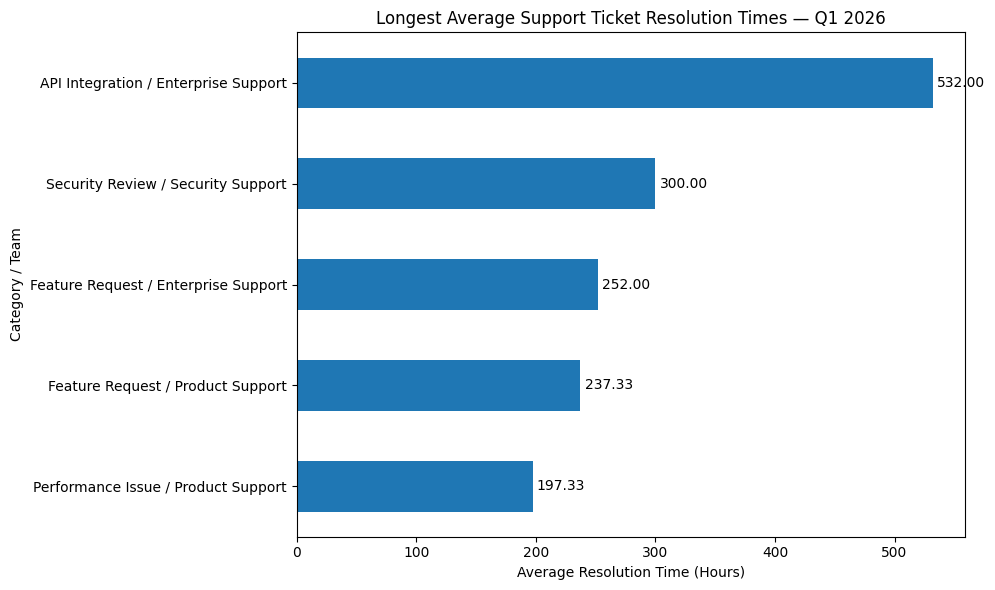

In [189]:
# Chart

import matplotlib.pyplot as plt

# Create labels for each category/team combination
chart_df = resolution_df.copy()

chart_df["category_team"] = (
    chart_df["category_name"] + " / " + chart_df["team_name"]
)

# Select the five longest average resolution times
top_5 = (
    chart_df
    .sort_values("avg_resolution_hours", ascending=False)
    .head(5)
    .sort_values("avg_resolution_hours")
)

# Create the chart
ax = top_5.plot(
    kind="barh",
    x="category_team",
    y="avg_resolution_hours",
    legend=False,
    figsize=(10, 6)
)

ax.set_title("Longest Average Support Ticket Resolution Times — Q1 2026")
ax.set_xlabel("Average Resolution Time (Hours)")
ax.set_ylabel("Category / Team")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

## Step 10: Evaluate and Verify the Output

Verify that the workflow produced a trustworthy result.


In [190]:
# Verify

# Verify the number of Q1 2026 resolved tickets
q1_count = pd.read_sql_query("""
SELECT COUNT(*) AS resolved_ticket_count
FROM tickets
WHERE status = 'Resolved'
  AND resolved_date >= '2026-01-01'
  AND resolved_date < '2026-04-01';
""", conn)

display(q1_count)

# Inspect the category/team combination with the highest average
verification_df = pd.read_sql_query("""
SELECT
    t.ticket_id,
    t.created_date,
    t.resolved_date,
    ROUND(
        (julianday(t.resolved_date) - julianday(t.created_date)) * 24,
        2
    ) AS resolution_hours
FROM tickets AS t
JOIN ticket_categories AS c
    ON t.category_id = c.category_id
JOIN teams AS tm
    ON t.team_id = tm.team_id
WHERE t.status = 'Resolved'
  AND t.resolved_date >= '2026-01-01'
  AND t.resolved_date < '2026-04-01'
  AND c.category_name = 'API Integration'
  AND tm.team_name = 'Enterprise Support'
ORDER BY resolution_hours;
""", conn)

display(verification_df)

print("Ticket count:", len(verification_df))
print("Mean:", verification_df["resolution_hours"].mean())
print("Median:", verification_df["resolution_hours"].median())

,resolved_ticket_count
0,131


,ticket_id,created_date,resolved_date,resolution_hours
0,138,2026-01-19,2026-01-25,144.0
1,115,2026-01-26,2026-02-04,216.0
2,203,2026-01-31,2026-02-13,312.0
3,286,2026-02-23,2026-03-08,312.0
4,124,2026-01-24,2026-02-10,408.0
5,452,2026-01-04,2026-03-20,1800.0


Ticket count: 6
Mean: 532.0
Median: 312.0


### Verification Notes

Address:

- Did the query use the actual table and column names?
- Did the query use the correct joins?
- Did the date filter match Q1 2026?
- Did the query include only resolved tickets?
- Did the resolution-time calculation make sense?
- Were there missing values, duplicates, small sample sizes, or unusual values?
- Did the chart match the DataFrame?
- Did your written conclusion stay within what the data supports?

[Write your verification notes here.]
> The query used the correct tables, columns, joins, Q1 2026 date range, and Resolved status. Resolution time was calculated correctly from created_date to resolved_date.

> The results had no missing values or duplicate ticket IDs, but some groups had small sample sizes. API Integration / Enterprise Support had the highest average at 532 hours across 6 tickets, including one unusually long 1,800-hour ticket, so the result should be interpreted cautiously.

> The chart matched resolution_df, and the written conclusion stayed within what the data supports.


## Step 11: Write a Supported Final Explanation

Include:

- The original question
- The main finding
- Evidence from your SQL-to-Python workflow
- One limitation or assumption
- One recommended next step for review

### Final Explanation

[Write your final explanation here.]
> The original question was which support ticket category/team combinations had the longest average resolution time in Q1 2026.

> The main finding was that API Integration / Enterprise Support had the longest average resolution time at 532 hours. The SQL query used the actual database tables and joins, filtered to Resolved tickets from 2026-01-01 through 2026-03-31, and the results were loaded into Pandas for review and charting. The analysis included 131 resolved tickets overall.

> One limitation is that the top result was based on only 6 tickets and included one unusually long 1,800-hour ticket, which raised the average. A useful next step would be to review the individual API Integration tickets, especially the outlier, to understand what caused the long resolution times.


## Step 12: Reflect on the Workflow

Answer:

- What was the most important step in making your result trustworthy?
- What issue or challenge did you need to check, debug, or refine?
- How did Identify → Assemble → Execute → Verify help you complete the workflow?
- How could this workflow be applied in another context?
- What would you improve if you repeated this analysis?
- What cloud constraint did you encounter, and how did you manage it?

### Reflection

[Write your reflection here.]
> The most important step was verifying the query against the actual database structure and checking the results after execution. I had to refine the workflow by confirming the correct table and column names, fixing the database file path in Colab, and checking that the Q1 2026 date filter and Resolved status were applied correctly.

> Identify → Assemble → Execute → Verify helped by separating the problem into clear stages: define the question, build the query from the real schema, run it, and then confirm that the output made sense. This same workflow could be used for other analyses such as customer support trends, sales performance, or healthcare operations.

> If I repeated the analysis, I would include ticket counts and median resolution time in the main query so outliers are easier to detect. The main cloud constraint was that the database was initially in Google Drive’s “Shared with me” area rather than the expected My Drive path, so I resolved it by making the file accessible from the mounted Drive location used by Colab.


## Close the Database Connection


In [191]:
conn.close()
print("Database connection closed.")


Database connection closed.
